## Seeds -> PepMLM -> MetaLATTE -> Predictions

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from PepMLM_gen_scripts.pepmlm_generate_fast import PepMLMConfig, run_pepmlm
from MetaLATTE_gen_scripts.run_metalatte_fasta import run_metalatte_on_fasta

# ====== CONFIG ======
SEEDS_FASTA = Path("PepMLM_seeds/Metal_specific/pb_mer_operon_seeds.fasta")
WORK_DIR    = Path("notebook_runs/run5_pb_metal_specific")  # change per experiment if you want


# PepMLM hyperparams
N_VARIANTS_PER_SEED = 20
FRACTION_MASK       = 0.10   # try 0.10 and maybe 0.15
TOPK_PER_MASK       = 3
MAX_LEN             = 200
BATCH_SIZE          = 16   # depending on memory
TOP_K               = 50 

WORK_DIR.mkdir(parents=True, exist_ok=True)
# ====== Save hyperparameters for reproducibility ======
import json

run_params = {
    "N_VARIANTS_PER_SEED": N_VARIANTS_PER_SEED,
    "FRACTION_MASK": FRACTION_MASK,
    "TOPK_PER_MASK": TOPK_PER_MASK,
    "MAX_LEN": MAX_LEN,
    "BATCH_SIZE": BATCH_SIZE,
    "TOP_K": TOP_K,
    "SEEDS_FASTA": str(SEEDS_FASTA),
    "WORK_DIR": str(WORK_DIR),
}

config_path = WORK_DIR / "run_config.json"
with open(config_path, "w") as f:
    json.dump(run_params, f, indent=4)

print(f"Saved run hyperparameters → {config_path}")

# ====== STEP 1: generate variants with PepMLM ======
print("Step 1: generating variants with PepMLM…")
variants_fasta = WORK_DIR / "generated_variants.fasta"

pep_cfg = PepMLMConfig(
    fasta_in=SEEDS_FASTA,
    fasta_out=variants_fasta,
    n_variants_per_seed=N_VARIANTS_PER_SEED,
    fraction_mask=FRACTION_MASK,
    topk_per_mask=TOPK_PER_MASK,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
)
run_pepmlm(pep_cfg)

# ====== STEP 2: run MetaLATTE on generated variants ======
print("Step 2: predicting binding with MetaLATTE…")
preds_csv = WORK_DIR / "metalatte_predictions.csv"
run_metalatte_on_fasta(
    fasta_path=str(variants_fasta),
    out_csv_path=str(preds_csv),
)

# ====== STEP 3: compute binding capacity + select top variants ======
print("Step 3: analyzing predictions…")
df = pd.read_csv(preds_csv)

# define metals as all prob_* columns except any Non-binding
metal_cols = [
    c for c in df.columns
    if c.startswith("prob_") and "Non" not in c
]

# binding capacity = max prob over metals
df["binding_capacity"] = df[metal_cols].max(axis=1)
df["best_metal"] = df[metal_cols].idxmax(axis=1).str.replace("prob_", "")

df_top = df.sort_values("binding_capacity", ascending=False).head(TOP_K)
top_csv = WORK_DIR / "top_variants.csv"
df_top.to_csv(top_csv, index=False)
print(f"Saved top {TOP_K} variants → {top_csv}")

# ====== STEP 4: plot top binding capacities ======
plots_dir = WORK_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_path = plots_dir / "top_binding_capacity_by_metal.png"

# sort by binding_capacity just like before
df_top = df.sort_values("binding_capacity", ascending=False).head(TOP_K)

plt.figure(figsize=(12, 4))

# unique metals in this top set
metals = sorted(df_top["best_metal"].unique())

# assign each metal an index, then use a colormap
metal_to_idx = {m: i for i, m in enumerate(metals)}
colors = plt.cm.tab20([metal_to_idx[m] % 20 for m in df_top["best_metal"]])

# Show top few rows inline
df_top.head()


Saved run hyperparameters → notebook_runs/run5_pb_metal_specific/run_config.json
Step 1: generating variants with PepMLM…
[17:23:02] loading PepMLM model/tokenizer…
[17:23:07] device: cpu; threads: 4
[17:23:07] seed sp_P38990_SAK1_YEAST (len 1142) …
[17:23:07] skip sp_P38990_SAK1_YEAST: length 1142 > MAX_LEN 200
[17:23:07] seed sp_P04034_LDH1_LACLC (len 325) …
[17:23:07] skip sp_P04034_LDH1_LACLC: length 325 > MAX_LEN 200
[17:23:07] seed sp_P04140_MERT_PSEAI (len 116) …
[17:23:15] seed sp_P25224_MATRX_RABVN (len 202) …
[17:23:15] skip sp_P25224_MATRX_RABVN: length 202 > MAX_LEN 200
[17:23:15] seed sp_Q9ZDL2_DHAS_RICPR (len 338) …
[17:23:15] skip sp_Q9ZDL2_DHAS_RICPR: length 338 > MAX_LEN 200
[17:23:15] seed tr_Q7MGP3_Q7MGP3_VIBVY (len 625) …
[17:23:15] skip tr_Q7MGP3_Q7MGP3_VIBVY: length 625 > MAX_LEN 200
[17:23:15] seed sp_P81803_TTF17_HADVE (len 68) …
[17:23:20] seed tr_Q9LT07_Q9LT07_ARATH (len 175) …
[17:23:33] seed tr_Q9ZDL3_Q9ZDL3_RICPR (len 583) …
[17:23:33] skip tr_Q9ZDL3_Q9ZDL3

Seed set to 42
Seed set to 42


Step 2: predicting binding with MetaLATTE…


Some weights of EsmModel were not initialized from the model checkpoint at /workarea/AML_Final_Project/esm2_local/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run5_pb_metal_specific/metalatte_predictions.csv
Step 3: analyzing predictions…
Saved top 50 variants → notebook_runs/run5_pb_metal_specific/top_variants.csv


,id,sequence,prob_Ag,prob_Cd,prob_Co,prob_Cu,prob_Fe,prob_Hg,prob_Mn,prob_Mo,prob_Ni,prob_Non-binding,prob_Pb,prob_Pt,prob_V,prob_W,prob_Zn,binding_capacity,best_metal
62,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_3,MTIIRKKHPLSKIINHSFIDLLAPSNISSWWNFGSLLGLCLLIQIA...,0.000161,0.000001,0.000013,0.000044,0.998154,0.000163,0.000101,0.000285,0.000064,0.009023,0.000016,0.000002,1.700412e-07,8.138149e-07,0.003656,0.998154,Fe
69,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_10,MTIIRKKHPSISIINHSMIDLPAYSNISSWWNFSVILGWCLIIQIL...,0.000161,0.000001,0.000014,0.000045,0.997283,0.000176,0.000131,0.000274,0.000078,0.009124,0.000016,0.000002,1.651989e-07,7.969114e-07,0.003199,0.997283,Fe
64,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_5,MDIIRKKHPLIEIINHSFSPLPAPSNISSWWNGGSLLGLCLIIQIL...,0.000165,0.000001,0.000016,0.000050,0.995949,0.000174,0.000129,0.000257,0.000092,0.009492,0.000017,0.000002,1.694979e-07,7.936464e-07,0.003810,0.995949,Fe
75,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_16,MFISRKKSPLIKIINHSFIDLPAPENISSWWNFQSLLGLCLIIQIL...,0.000167,0.000002,0.000017,0.000052,0.994281,0.000192,0.000156,0.000249,0.000119,0.009671,0.000017,0.000002,1.676561e-07,7.867796e-07,0.003371,0.994281,Fe
66,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_7,MTIIRKLHPFIKIINHSFIDLPAGSNISSWWVFGSLLGLCLIIQIL...,0.000166,0.000002,0.000017,0.000052,0.994127,0.000188,0.000159,0.000248,0.000116,0.009532,0.000017,0.000002,1.648039e-07,7.849127e-07,0.003159,0.994127,Fe


<Figure size 1200x400 with 0 Axes>

## compare max binding per metal: seeds vs novel variant

Seed set to 42


Step 5: comparing seeds vs novel variants…
Running MetaLATTE on seed proteins…


Some weights of EsmModel were not initialized from the model checkpoint at /workarea/AML_Final_Project/esm2_local/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run5_pb_metal_specific/predictions_seeds.csv


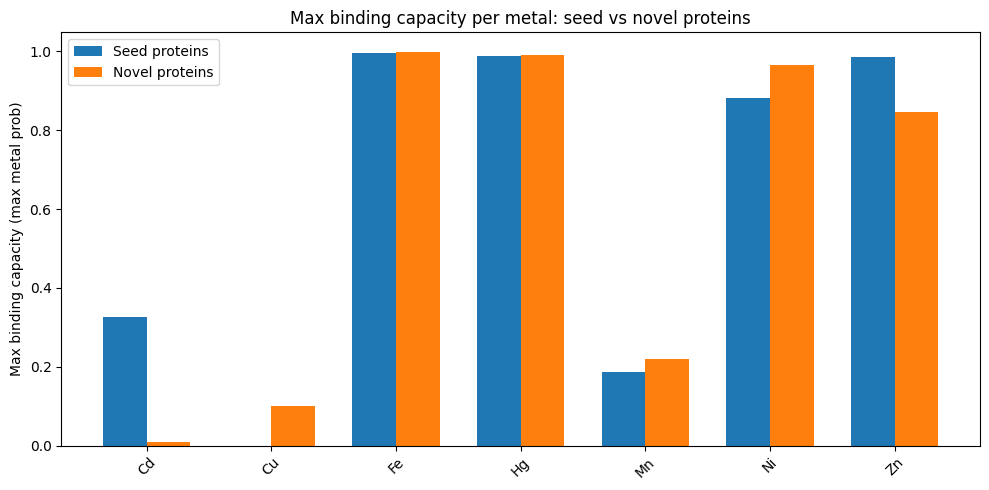

Saved comparison plot → notebook_runs/run5_pb_metal_specific/plots/max_binding_capacity_seeds_vs_novels_by_metal.png


source,novel,seed
best_metal,,
Cd,0.009769,0.325836
Cu,0.101361,0.000000
Fe,0.998154,0.995278
Hg,0.991612,0.987051
Mn,0.218883,0.186526
Ni,0.964275,0.881653
Zn,0.846354,0.985058


In [2]:
# ====== EXTRA STEP: compare max binding per metal: seeds vs novel variants ======

print("Step 5: comparing seeds vs novel variants…")

# 1) Run MetaLATTE on the seed FASTA (if not already done)
seeds_preds_csv = WORK_DIR / "predictions_seeds.csv"
if not seeds_preds_csv.exists():
    print("Running MetaLATTE on seed proteins…")
    run_metalatte_on_fasta(
        fasta_path=str(SEEDS_FASTA),
        out_csv_path=str(seeds_preds_csv),
    )
else:
    print("Found existing seed predictions →", seeds_preds_csv)

# 2) Load predictions for seeds and variants
df_seeds = pd.read_csv(seeds_preds_csv)
df_novel = df.copy()  # predictions on generated variants from earlier

# 3) Helper to add binding info
def add_binding_info(df_in, source_label):
    df_tmp = df_in.copy()
    metal_cols = [c for c in df_tmp.columns if c.startswith("prob_") and "Non" not in c]
    df_tmp["binding_capacity"] = df_tmp[metal_cols].max(axis=1)
    df_tmp["best_metal"] = df_tmp[metal_cols].idxmax(axis=1).str.replace("prob_", "")
    df_tmp["source"] = source_label
    return df_tmp[["id", "binding_capacity", "best_metal", "source"]]

df_seeds_bc = add_binding_info(df_seeds, source_label="seed")
df_novel_bc = add_binding_info(df_novel, source_label="novel")

df_all = pd.concat([df_seeds_bc, df_novel_bc], ignore_index=True)

# 4) Compute max binding per metal per source
summary = (
    df_all
    .groupby(["best_metal", "source"])["binding_capacity"]
    .max()
    .reset_index()
)

pivot = summary.pivot(index="best_metal", columns="source", values="binding_capacity").fillna(0)

# 5) Plot side-by-side bars
plots_dir = WORK_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
compare_plot_path = plots_dir / "max_binding_capacity_seeds_vs_novels_by_metal.png"

plt.figure(figsize=(10, 5))

metals = pivot.index.tolist()
x = range(len(metals))
width = 0.35

seed_vals  = pivot["seed"]  if "seed"  in pivot.columns else pd.Series(0, index=pivot.index)
novel_vals = pivot["novel"] if "novel" in pivot.columns else pd.Series(0, index=pivot.index)

plt.bar([i - width/2 for i in x], seed_vals,  width=width, label="Seed proteins")
plt.bar([i + width/2 for i in x], novel_vals, width=width, label="Novel proteins")

plt.xticks(list(x), metals, rotation=45)
plt.ylabel("Max binding capacity (max metal prob)")
plt.title("Max binding capacity per metal: seed vs novel proteins")
plt.legend()
plt.tight_layout()

plt.savefig(compare_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved comparison plot → {compare_plot_path}")
pivot


In [3]:
# ====== Show top N highest-binding proteins overall ======
TOP_N = 20  # change as desired

df_all_sorted = df_all.sort_values("binding_capacity", ascending=False)

display(df_all_sorted.head(TOP_N))


,id,binding_capacity,best_metal,source
79,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_3,0.998154,Fe,novel
86,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_10,0.997283,Fe,novel
81,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_5,0.995949,Fe,novel
9,tr|Q9ZXN7|Q9ZXN7_9RODE Cytochrome b (Fragment)...,0.995278,Fe,seed
92,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_16,0.994281,Fe,novel
83,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_7,0.994127,Fe,novel
82,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_6,0.994101,Fe,novel
95,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_19,0.994021,Fe,novel
91,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_15,0.993933,Fe,novel
93,gen_tr_Q9ZXN7_Q9ZXN7_9RODE_17,0.993634,Fe,novel


## Novelty Percentage

/usr/bin/sh: pip: command not found
Step: Computing sequence similarity (novels vs seeds)…
Loaded 17 seed sequences and 120 novel sequences from FASTA.
Computed pairwise identity matrix: 120 novels × 17 seeds.
Derived max identity and novelty scores for each novel.


,id,best_seed_id,max_seq_identity_to_seed,novelty_score
0,gen_sp_P04140_MERT_PSEAI_1,sp|P04140|MERT_PSEAI,0.896552,0.103448
1,gen_sp_P04140_MERT_PSEAI_2,sp|P04140|MERT_PSEAI,0.922414,0.077586
2,gen_sp_P04140_MERT_PSEAI_3,sp|P04140|MERT_PSEAI,0.905172,0.094828
3,gen_sp_P04140_MERT_PSEAI_4,sp|P04140|MERT_PSEAI,0.913793,0.086207
4,gen_sp_P04140_MERT_PSEAI_5,sp|P04140|MERT_PSEAI,0.905172,0.094828



Similarity threshold: max_seq_identity_to_seed ≤ 0.98
Filtered novels count: 120 / 120 novel proteins


,id,binding_capacity,best_metal,source,best_seed_id,max_seq_identity_to_seed,novelty_score
17,gen_sp_P04140_MERT_PSEAI_1,0.929437,Hg,novel,sp|P04140|MERT_PSEAI,0.896552,0.103448
18,gen_sp_P04140_MERT_PSEAI_2,0.926722,Hg,novel,sp|P04140|MERT_PSEAI,0.922414,0.077586
19,gen_sp_P04140_MERT_PSEAI_3,0.878846,Hg,novel,sp|P04140|MERT_PSEAI,0.905172,0.094828
20,gen_sp_P04140_MERT_PSEAI_4,0.304391,Hg,novel,sp|P04140|MERT_PSEAI,0.913793,0.086207
21,gen_sp_P04140_MERT_PSEAI_5,0.984188,Hg,novel,sp|P04140|MERT_PSEAI,0.905172,0.094828


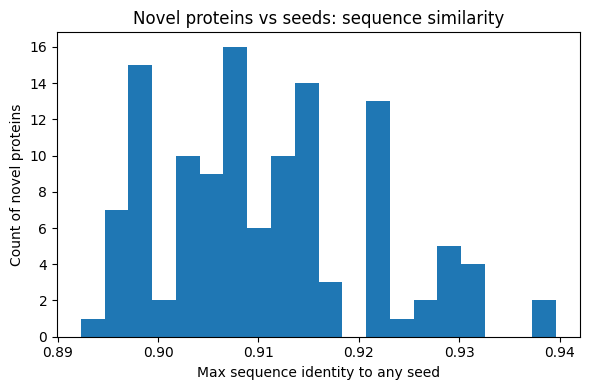

Saved similarity histogram → notebook_runs/run5_pb_metal_specific/plots/novel_vs_seed_similarity_histogram.png


In [7]:
# ====== ONE CELL: similarity + novelty + threshold filter (+ optional heatmap) ======

!pip install biopython --quiet

from Bio import SeqIO, pairwise2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Step: Computing sequence similarity (novels vs seeds)…")

# ------------------------------------------------------------------
# 1. Load seed & novel sequences from FASTA (use ALL IDs)
# ------------------------------------------------------------------

def read_fasta_to_dict(path):
    """Return {seq_id: amino_acid_sequence} dictionary."""
    records = {}
    for rec in SeqIO.parse(str(path), "fasta"):
        records[rec.id] = str(rec.seq)
    return records

seed_seqs  = read_fasta_to_dict(SEEDS_FASTA)
novel_seqs = read_fasta_to_dict(variants_fasta)

seed_ids  = list(seed_seqs.keys())
novel_ids = list(novel_seqs.keys())

print(f"Loaded {len(seed_ids)} seed sequences and {len(novel_ids)} novel sequences from FASTA.")

if len(seed_ids) == 0 or len(novel_ids) == 0:
    raise ValueError("No seed or novel sequences found in the FASTA files. "
                     "Check SEEDS_FASTA and variants_fasta paths / contents.")

# ------------------------------------------------------------------
# 2. Global percent identity function
# ------------------------------------------------------------------

def global_percent_identity(seq1, seq2):
    """
    Global alignment using Biopython's globalxx:
    match = 1, mismatch = 0, no gap penalties.
    Percent identity = matches / alignment_length.
    """
    aln = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)[0]
    score = aln.score                    # number of matches
    aln_len = max(len(seq1), len(seq2))
    return score / aln_len

# ------------------------------------------------------------------
# 3. Build pairwise identity matrix: novels x seeds
# ------------------------------------------------------------------

pid_matrix = np.zeros((len(novel_ids), len(seed_ids)), dtype=float)

for i, n_id in enumerate(novel_ids):
    n_seq = novel_seqs[n_id]
    for j, s_id in enumerate(seed_ids):
        s_seq = seed_seqs[s_id]
        pid_matrix[i, j] = global_percent_identity(n_seq, s_seq)

pid_df = pd.DataFrame(pid_matrix, index=novel_ids, columns=seed_ids)

print("Computed pairwise identity matrix: "
      f"{pid_df.shape[0]} novels × {pid_df.shape[1]} seeds.")

# Guard: should not be empty, but just in case
if pid_df.shape[0] == 0 or pid_df.shape[1] == 0:
    raise ValueError("Pairwise identity matrix is empty; cannot compute argmax. "
                     "Check that your FASTA files contain valid sequences.")

# ------------------------------------------------------------------
# 4. Derive per-novel max identity, best seed, novelty score
# ------------------------------------------------------------------

max_pid = pid_df.max(axis=1)             # per novel (row)
best_seed_idx = pid_df.idxmax(axis=1)    # seed ID with highest identity

df_novel_sim = pd.DataFrame({
    "id": pid_df.index.astype(str),
    "best_seed_id": best_seed_idx.values,
    "max_seq_identity_to_seed": max_pid.values,
})
df_novel_sim["novelty_score"] = 1.0 - df_novel_sim["max_seq_identity_to_seed"]

print("Derived max identity and novelty scores for each novel.")
display(df_novel_sim.head())

# ------------------------------------------------------------------
# 5. Merge similarity info into df_all
# ------------------------------------------------------------------

df_all_with_sim = df_all.copy()
df_all_with_sim["id"] = df_all_with_sim["id"].astype(str)

df_all_with_sim = df_all_with_sim.merge(df_novel_sim, on="id", how="left")

# ------------------------------------------------------------------
# 6. Filter novels by similarity threshold
# ------------------------------------------------------------------

SIM_THRESHOLD = 0.98  # <-- change this to tune novelty (e.g. 0.6, 0.8, etc.)

is_novel = df_all_with_sim["source"] == "novel"
mask_pass = (
    is_novel &
    df_all_with_sim["max_seq_identity_to_seed"].notna() &
    (df_all_with_sim["max_seq_identity_to_seed"] <= SIM_THRESHOLD)
)

filtered_novels = df_all_with_sim[mask_pass].copy()

print(f"\nSimilarity threshold: max_seq_identity_to_seed ≤ {SIM_THRESHOLD}")
print(f"Filtered novels count: {len(filtered_novels)} / {is_novel.sum()} novel proteins")

display(filtered_novels.head())

# ====== Save the similarity plot to the plots directory ======

plots_dir = WORK_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

similarity_plot_path = plots_dir / "novel_vs_seed_similarity_histogram.png"

plt.figure(figsize=(6, 4))
plt.hist(df_all_with_sim["max_seq_identity_to_seed"].dropna(), bins=20)
plt.xlabel("Max sequence identity to any seed")
plt.ylabel("Count of novel proteins")
plt.title("Novel proteins vs seeds: sequence similarity")
plt.tight_layout()

plt.savefig(similarity_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved similarity histogram → {similarity_plot_path}")



In [ ]:
filtered_novels

,id,binding_capacity,best_metal,source,best_seed_id,max_seq_identity_to_seed,novelty_score
17,gen_sp_P04140_MERT_PSEAI_1,0.929437,Hg,novel,sp|P04140|MERT_PSEAI,0.896552,0.103448
18,gen_sp_P04140_MERT_PSEAI_2,0.926722,Hg,novel,sp|P04140|MERT_PSEAI,0.922414,0.077586
19,gen_sp_P04140_MERT_PSEAI_3,0.878846,Hg,novel,sp|P04140|MERT_PSEAI,0.905172,0.094828
20,gen_sp_P04140_MERT_PSEAI_4,0.304391,Hg,novel,sp|P04140|MERT_PSEAI,0.913793,0.086207
21,gen_sp_P04140_MERT_PSEAI_5,0.984188,Hg,novel,sp|P04140|MERT_PSEAI,0.905172,0.094828
...,...,...,...,...,...,...,...
132,gen_tr_Q9RFJ9_Q9RFJ9_ACTPL_16,0.819288,Zn,novel,tr|Q9RFJ9|Q9RFJ9_ACTPL,0.923077,0.076923
133,gen_tr_Q9RFJ9_Q9RFJ9_ACTPL_17,0.511544,Zn,novel,tr|Q9RFJ9|Q9RFJ9_ACTPL,0.900000,0.100000
134,gen_tr_Q9RFJ9_Q9RFJ9_ACTPL_18,0.428646,Zn,novel,tr|Q9RFJ9|Q9RFJ9_ACTPL,0.907692,0.092308
135,gen_tr_Q9RFJ9_Q9RFJ9_ACTPL_19,0.363095,Zn,novel,tr|Q9RFJ9|Q9RFJ9_ACTPL,0.915385,0.084615


: 